In [34]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import norm

In [ ]:
# value a bond
def bond_price(face_value, coupon_rate, ttm, market_rate, n_periods=1):
    periods = ttm * n_periods
    coupon = face_value * (coupon_rate / n_periods)
    r = market_rate / n_periods
    total_coupons = 0
    for i in range(1, periods + 1):
        current = coupon / ((1 + r)**i)
        total_coupons += current
    pvfv = face_value / ((1 + r)**periods)
    price = total_coupons + pvfv
    if price > face_value:
        type = "premium"
    elif price < face_value:
        type = "discount"
    else:
        type = "par"
    return price, type
bond_price(1000, 0.06, 30, 0.08, 1)


(774.8443331374496, 'discount')

In [ ]:
# get yield-to-maturity from price
def solve_ytm(price, face, coupon_rate, ttm, n_periods=1):
    low = 0.0001
    high = 1.0
    for x in range(100):
        mid = (low + high) / 2
        val = bond_price(face, coupon_rate, ttm, mid, n_periods)
        if val > price:
            low = mid
        else:
            high = mid
    return mid


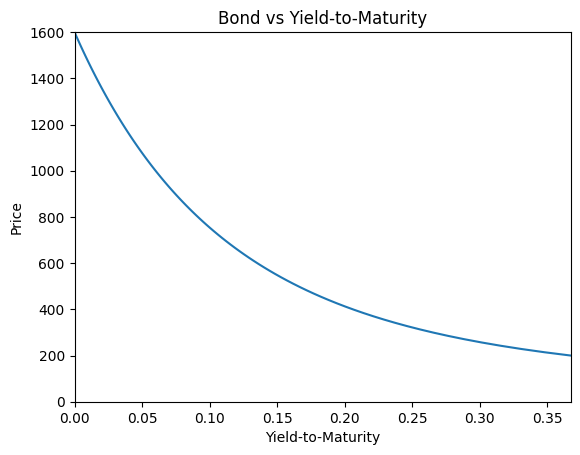

In [ ]:
def bond_to_ytm_plot(face, coupon, ttm, n_periods=1):
    price_vals = np.linspace(200,1600,100)
    ytms = []
    for price in price_vals:
        ytm = solve_ytm(price, face, coupon, ttm, n_periods)
        ytms.append(ytm)
    plt.plot(ytms, price_vals)
    plt.xlabel("Yield-to-Maturity")
    plt.ylim(0, max(price_vals))
    plt.xlim(0, max(ytms))
    plt.title("Bond vs Yield-to-Maturity")
    plt.ylabel("Price")
bond_to_ytm_plot(1000, 0.06, 10, 1)

In [ ]:
# Stock valuation model using ggm/ddm
# g = 0 for no growth
def ggm(dividend, r, g):
    if not r > g:
        return "Discount Rate needs to be greater than Growth Rate"
    total = dividend*(1+g) / (r-g)
    return total
ggm(3, 0.5, 0.2)

12.0

In [37]:
# futures financial asset valuation
def futures(spot, rfr, annual_dividend, T):
    q = annual_dividend / spot
    value = spot * (np.exp((rfr-q)*T))
    return value

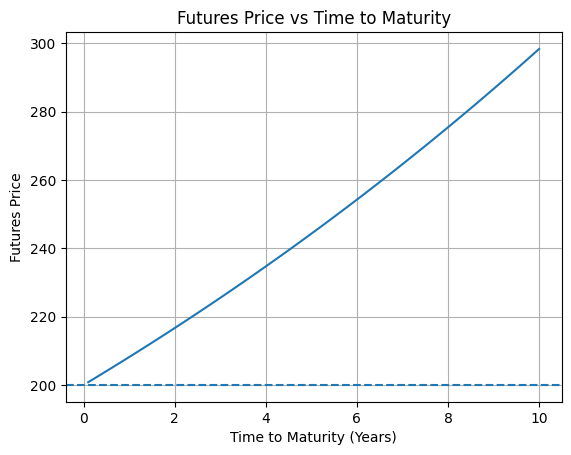

In [ ]:
T_vals = np.linspace(0.1, 10, 100)
futures_vals = futures(200, 0.05, 2, T_vals)
fig20, ax20 = plt.subplots()
ax20.set_xlabel("Time to Maturity (Years)")
ax20.set_ylabel("Futures Price")
ax20.set_title("Futures Price vs Time to Maturity")
ax20.grid()
ax20.plot(T_vals, futures_vals) 

In [41]:
# european options
def black_scholes_merton(S, K, T, r, sigma, option_type="call"):
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        raise ValueError("S, K, T, and sigma must be positive numbers.")
    if option_type not in ("call", "put"):
        raise ValueError("option_type must be 'call' or 'put'.")
    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    if option_type == "call":
        price = S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    else:  # put
        price = K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

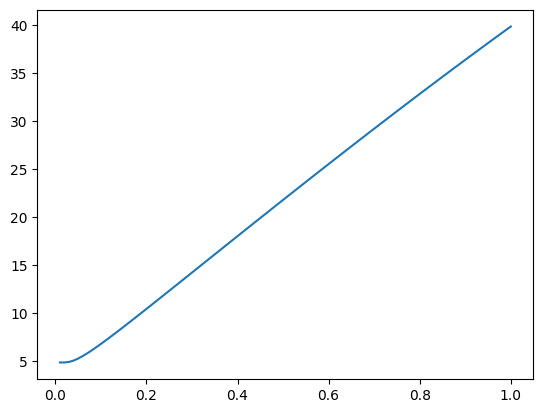

In [50]:
sigmas = np.linspace(0.01, 1.0, 100)
prices = [black_scholes_merton(100, 100, 1, 0.05, s, "call") for s in sigmas]

plt.plot(sigmas, prices)

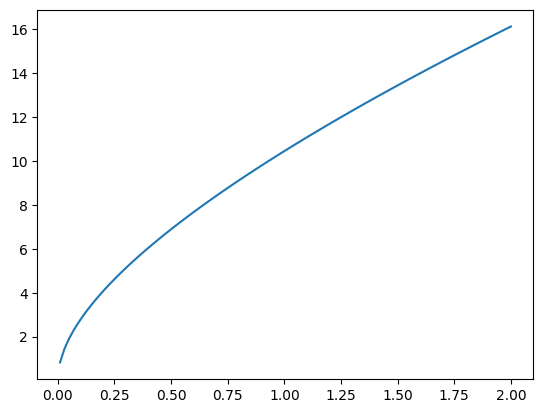

In [51]:
T_vals = np.linspace(0.01, 2, 100)
prices = [black_scholes_merton(100, 100, t, 0.05, 0.20, "call") for t in T_vals]

plt.plot(T_vals, prices)

In [ ]:
def greeks(S, K, T, r, sigma, option_type="call"):
    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    pdf = norm.pdf(d1)
    if option_type == "call":
        delta = norm.cdf(d1)
        theta = -(S * pdf * sigma) / (2 * math.sqrt(T)) - r * K * math.exp(-r*T) * norm.cdf(d2)
        rho = K * T * math.exp(-r*T) * norm.cdf(d2)
    elif option_type == "put":
        delta = norm.cdf(d1) - 1
        rho = -K * T * math.exp(-r*T) * norm.cdf(-d2)
        theta = -(S * pdf * sigma) / (2 * math.sqrt(T)) + r * K * math.exp(-r*T) * norm.cdf(-d2)
    gamma = pdf / (S * sigma * math.sqrt(T))
    vega = S * pdf * math.sqrt(T)
    return delta, gamma, vega, theta, rho